# Sentimental Analysis for Tweets .



# IMPORTING NECESSARY LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import nltk
import string
from nltk.tokenize import word_tokenize

In [2]:
dataset = pd.read_csv("sentiment_tweets3.csv")

In [3]:
dataset

,Index,message to examine,label (depression result)
0,106,just had a real good moment. i missssssssss hi...,0
1,217,is reading manga http://plurk.com/p/mzp1e,0
2,220,@comeagainjen http://twitpic.com/2y2lx - http:...,0
3,288,@lapcat Need to send 'em to my accountant tomo...,0
4,540,ADD ME ON MYSPACE!!! myspace.com/LookThunder,0
...,...,...,...
10309,802309,No Depression by G Herbo is my mood from now o...,1
10310,802310,What do you do when depression succumbs the br...,1
10311,802311,Ketamine Nasal Spray Shows Promise Against Dep...,1
10312,802312,dont mistake a bad day with depression! everyo...,1


In [4]:
dataset= dataset.rename(columns = {"message to examine":"text", "label (depression result)" :"Category" })
dataset

,Index,text,Category
0,106,just had a real good moment. i missssssssss hi...,0
1,217,is reading manga http://plurk.com/p/mzp1e,0
2,220,@comeagainjen http://twitpic.com/2y2lx - http:...,0
3,288,@lapcat Need to send 'em to my accountant tomo...,0
4,540,ADD ME ON MYSPACE!!! myspace.com/LookThunder,0
...,...,...,...
10309,802309,No Depression by G Herbo is my mood from now o...,1
10310,802310,What do you do when depression succumbs the br...,1
10311,802311,Ketamine Nasal Spray Shows Promise Against Dep...,1
10312,802312,dont mistake a bad day with depression! everyo...,1


# Data Preprocessing

In [5]:
dataset = dataset[["text", "Category"]]
dataset

,text,Category
0,just had a real good moment. i missssssssss hi...,0
1,is reading manga http://plurk.com/p/mzp1e,0
2,@comeagainjen http://twitpic.com/2y2lx - http:...,0
3,@lapcat Need to send 'em to my accountant tomo...,0
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,0
...,...,...
10309,No Depression by G Herbo is my mood from now o...,1
10310,What do you do when depression succumbs the br...,1
10311,Ketamine Nasal Spray Shows Promise Against Dep...,1
10312,dont mistake a bad day with depression! everyo...,1


In [6]:
dataset.shape
print("the number of row : ",dataset.shape[0])
print("the number of column : ",dataset.shape[1])

the number of row :  10314
the number of column :  2


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10314 entries, 0 to 10313
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10314 non-null  object
 1   Category  10314 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 161.3+ KB


In [8]:
dataset.isnull().sum()

text        0
Category    0
dtype: int64

In [9]:
dataset.duplicated().sum()
print("the number of duplicated values: ",dataset.duplicated().sum())

the number of duplicated values:  31


In [10]:
dataset = dataset.drop_duplicates()

In [11]:
# THE SHAPE AFTER REMOVING DUPLICATE VALUES
dataset.shape
print("the number of row after removing  duplicated values  : ",dataset.shape[0])
print("the number of column : ",dataset.shape[1])

the number of row after removing  duplicated values  :  10283
the number of column :  2


In [12]:
dataset["Category"].unique()

array([0, 1], dtype=int64)

In [13]:
dataset['Category'] = dataset['Category'].replace(0,'Not Depressed')
dataset['Category'] = dataset['Category'].replace(1,'Depressed')

<ipython-input-13-6ac24c686fc0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Category'] = dataset['Category'].replace(0,'Not Depressed')
<ipython-input-13-6ac24c686fc0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Category'] = dataset['Category'].replace(1,'Depressed')


In [14]:
dataset

,text,Category
0,just had a real good moment. i missssssssss hi...,Not Depressed
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed
...,...,...
10309,No Depression by G Herbo is my mood from now o...,Depressed
10310,What do you do when depression succumbs the br...,Depressed
10311,Ketamine Nasal Spray Shows Promise Against Dep...,Depressed
10312,dont mistake a bad day with depression! everyo...,Depressed


In [15]:
dataset["Category"].value_counts()

Category
Not Depressed    7996
Depressed        2287
Name: count, dtype: int64

Text(0.5, 1.0, 'COUNTS OF CATEGORIES OF BEING DEPRESSED OR NOT')

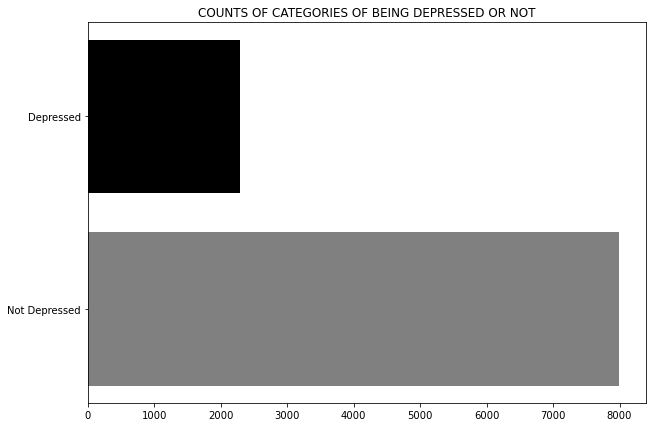

In [19]:
fig = plt.figure(figsize=(10, 7))
plt.barh(dataset["Category"].unique(), dataset["Category"].value_counts(), 
         color=['gray', 'black'])
plt.title("COUNTS OF CATEGORIES OF BEING DEPRESSED OR NOT")

In [20]:
from nltk.classify import NaiveBayesClassifier
from nltk.tokenize import word_tokenize
from collections import Counter

# Process the text 


In [21]:
dataset['text']

0        just had a real good moment. i missssssssss hi...
1               is reading manga  http://plurk.com/p/mzp1e
2        @comeagainjen http://twitpic.com/2y2lx - http:...
3        @lapcat Need to send 'em to my accountant tomo...
4            ADD ME ON MYSPACE!!!  myspace.com/LookThunder
                               ...                        
10309    No Depression by G Herbo is my mood from now o...
10310    What do you do when depression succumbs the br...
10311    Ketamine Nasal Spray Shows Promise Against Dep...
10312    dont mistake a bad day with depression! everyo...
10313                                                    0
Name: text, Length: 10283, dtype: object

In [24]:
dataset.columns

Index(['text', 'Category'], dtype='object')

In [25]:
dataset['text_cleaned'] = dataset['text'].str.lower()
dataset.head()

<ipython-input-25-16203f837e3d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text'].str.lower()


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,just had a real good moment. i missssssssss hi...
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,is reading manga http://plurk.com/p/mzp1e
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,@comeagainjen http://twitpic.com/2y2lx - http:...
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,@lapcat need to send 'em to my accountant tomo...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add me on myspace!!! myspace.com/lookthunder


1-romoving stop words

In [26]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = [word.lower() for word in text.split() if word.lower() not in stop_words]
    return " ".join(words)

dataset['text_cleaned'] = dataset['text_cleaned'].apply(remove_stopwords)
dataset.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\96277\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
<ipython-input-26-bc0d8a884f08>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(remove_stopwords)


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,"real good moment. missssssssss much,"
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga http://plurk.com/p/mzp1e
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,@comeagainjen http://twitpic.com/2y2lx - http:...
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,@lapcat need send 'em accountant tomorrow. odd...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace!!! myspace.com/lookthunder


2-Cleaning URLs

In [27]:
def clean_url(data):
    data=re.sub(r"((https:|http|ftp)?(:\/\/)?(www\.)?)?[-a-zA-Z0-9@:%._\+~#=]{1,256}\.[a-zA-Z0-9()]{1,6}\b([-a-zA-Z0-9()@:%_\+.~#?&\/\/=]*)",' ',data)
    return re.sub(r'/', ' / ', data)
dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_url(x))
dataset.head()

<ipython-input-27-7d370f99205b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_url(x))


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,"real good moment. missssssssss much,"
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,@comeagainjen -
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,@lapcat need send 'em accountant tomorrow. odd...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace!!!


3 - Cleaning Punctuations

In [28]:
import string
def clean_punctuations(text):
    return text.translate(str.maketrans('', '', string.punctuation))
dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_punctuations(x))
dataset.head()

<ipython-input-28-dc1e1349e14a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_punctuations(x))


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment missssssssss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace


4 - repeating_char

In [29]:
def clean_repeating_char(text):
    return re.sub(r"(.)\1\1+", r"\1\1", text)
dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_repeating_char(x))
dataset.head()

<ipython-input-29-0506098274a8>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_repeating_char(x))


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace


5 - Cleaning Numbers

In [30]:
def clean_numbers(data):
    return re.sub('[0-9]+', '', data)
dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_numbers(x))
dataset.head()

<ipython-input-30-513026fa5501>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_numbers(x))


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace


6 - remove hashtag


In [31]:
def remove_hashtag(data):
    return re.sub('#[\w\d]+',' ' ,data)
dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: remove_hashtag(x))
dataset.head()

<ipython-input-31-d6f1a80c77d9>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: remove_hashtag(x))


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace


7 - clean username

In [32]:
def clean_username(data):
    return re.sub('@[^\s]+',' ', data)
dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_username(x))
dataset.head()

<ipython-input-32-140ab2396a4c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_username(x))


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace


8 - clean emoji

In [33]:
def clean_emoji(data):    
    data = re.sub(r'<3', '<heart>', data)
    data = re.sub(r"[8:=;]['`\-]?[)d]+", '<smile>', data)
    data = re.sub(r"[8:=;]['`\-]?\(+", '<sad>', data)
    data = re.sub(r"[8:=;]['`\-]?[\/|l*]", '<neutral>', data)
    data = re.sub(r"[8:=;]['`\-]?p+", '<laugh>', data)
    return data
dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_emoji(x))
dataset.head()

<ipython-input-33-8e45455ab601>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(lambda x: clean_emoji(x))


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace


9 - remove images

In [34]:
def remove_images(tweet):
    cleaned_tweet = re.sub(r"pic\.twitter\.com/\S+",'', tweet)
    cleaned_tweet = re.sub("\w+(\.png|\.jpg|\.gif|\.jpeg)", " ", cleaned_tweet)
    return cleaned_tweet

dataset['text_cleaned'] = dataset['text_cleaned'].apply(remove_images)
dataset.head(10)

<ipython-input-34-41c79026ad44>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_cleaned'] = dataset['text_cleaned'].apply(remove_images)


,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace
5,so sleepy. good times tonight though,Not Depressed,sleepy good times tonight though
6,"@SilkCharm re: #nbn as someone already said, d...",Not Depressed,silkcharm re nbn someone already said fiber ho...
7,23 or 24ï¿½C possible today. Nice,Not Depressed,ï¿½c possible today nice
8,nite twitterville workout in the am -ciao,Not Depressed,nite twitterville workout ciao
9,"@daNanner Night, darlin'! Sweet dreams to you",Not Depressed,dananner night darlin sweet dreams


In [35]:
dataset.sample(10)

,text,Category,text_cleaned
3085,@whoaitsjess Ah I love that songg,Not Depressed,whoaitsjess ah love songg
3398,@megan_lanz great news! thanks for the link!,Not Depressed,meganlanz great news thanks link
3688,I can't get over the weather I'm loving it!!,Not Depressed,cant get weather loving it
1044,"@ben_mayer I'd like to see a picture of you, C...",Not Depressed,benmayer like see picture you carl john everyo...
7472,@daonde pooo a gente tem q viver offline tbm n...,Not Depressed,daonde poo gente tem q viver offline tbm nã© f...
7480,has finally finished all of his exams!,Not Depressed,finally finished exams
4584,http://looklet.com/ Try it try it,Not Depressed,try try
8657,My depression: pic.twitter.com/aP6j1pLFXb,Depressed,depression
8821,@stefsanjati @kelseybl4ck @allthesedoubts inte...,Depressed,stefsanjati kelseyblck allthesedoubts interest...
10059,Hay fever increases the risk of depression ht...,Depressed,hay fever increases risk depression https â


In [36]:
dataset

,text,Category,text_cleaned
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace
...,...,...,...
10309,No Depression by G Herbo is my mood from now o...,Depressed,depression g herbo mood on done stressing peop...
10310,What do you do when depression succumbs the br...,Depressed,depression succumbs brain makes feel like neve...
10311,Ketamine Nasal Spray Shows Promise Against Dep...,Depressed,ketamine nasal spray shows promise depression ...
10312,dont mistake a bad day with depression! everyo...,Depressed,dont mistake bad day depression everyone em


10 - lemmatizer

In [37]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


lemmatizer = WordNetLemmatizer()

In [43]:
nltk.download('punkt')
nltk.download('wordnet')
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem import PorterStemmer
!unzip /root/nltk_data/corpora/wordnet.zip -d /root/nltk_data/corpora/
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem import PorterStemmer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\96277\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\96277\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
unzip:  cannot find either /root/nltk_data/corpora/wordnet.zip or /root/nltk_data/corpora/wordnet.zip.zip.


In [44]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\96277\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
lemmatizer = nltk.stem.wordnet.WordNetLemmatizer()
def lemmatizeRows(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])
dataset['lemmatizedRows'] = dataset['text_cleaned'].apply(lemmatizeRows)
dataset.head()

<ipython-input-46-ded0363ca5d6>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['lemmatizedRows'] = dataset['text_cleaned'].apply(lemmatizeRows)


,text,Category,text_cleaned,lemmatizedRows
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga,reading manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...,lapcat need send em accountant tomorrow oddly ...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace,add myspace


11 - Stemming

In [47]:
stemmer = PorterStemmer()

def stemRows(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

dataset['stemmedRows'] = dataset['lemmatizedRows'].apply(stemRows)

dataset.head()

<ipython-input-47-070609a42dcb>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['stemmedRows'] = dataset['lemmatizedRows'].apply(stemRows)


,text,Category,text_cleaned,lemmatizedRows,stemmedRows
0,just had a real good moment. i missssssssss hi...,Not Depressed,real good moment miss much,real good moment miss much,real good moment miss much
1,is reading manga http://plurk.com/p/mzp1e,Not Depressed,reading manga,reading manga,read manga
2,@comeagainjen http://twitpic.com/2y2lx - http:...,Not Depressed,comeagainjen,comeagainjen,comeagainjen
3,@lapcat Need to send 'em to my accountant tomo...,Not Depressed,lapcat need send em accountant tomorrow oddly ...,lapcat need send em accountant tomorrow oddly ...,lapcat need send em account tomorrow oddli eve...
4,ADD ME ON MYSPACE!!! myspace.com/LookThunder,Not Depressed,add myspace,add myspace,add myspac


In [48]:
dataset.isnull().sum()

text              0
Category          0
text_cleaned      0
lemmatizedRows    0
stemmedRows       0
dtype: int64

# Build a Naive Bayes mode

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = dataset['lemmatizedRows']
y = dataset['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train_vectorized, y_train)

y_pred = naive_bayes_model.predict(X_test_vectorized)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_rep)

Accuracy: 98.49%
Confusion Matrix:
 [[ 442    7]
 [  24 1584]]
Classification Report:
                precision    recall  f1-score   support

    Depressed       0.95      0.98      0.97       449
Not Depressed       1.00      0.99      0.99      1608

     accuracy                           0.98      2057
    macro avg       0.97      0.98      0.98      2057
 weighted avg       0.99      0.98      0.99      2057



In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vectorized, y_train)
y_pred_lr = lr_model.predict(X_test_vectorized)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression")
print(f"Accuracy: {lr_accuracy:.2%}")
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vectorized, y_train)
y_pred_rf = rf_model.predict(X_test_vectorized)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest")
print(f"Accuracy: {rf_accuracy:.2%}")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
Accuracy: 99.61%
               precision    recall  f1-score   support

    Depressed       1.00      0.98      0.99       449
Not Depressed       1.00      1.00      1.00      1608

     accuracy                           1.00      2057
    macro avg       1.00      0.99      0.99      2057
 weighted avg       1.00      1.00      1.00      2057

Random Forest
Accuracy: 94.94%
               precision    recall  f1-score   support

    Depressed       0.82      0.99      0.90       449
Not Depressed       1.00      0.94      0.97      1608

     accuracy                           0.95      2057
    macro avg       0.91      0.96      0.93      2057
 weighted avg       0.96      0.95      0.95      2057



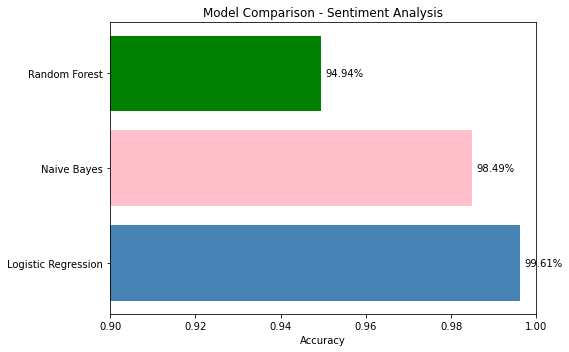

In [52]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
accuracies = [lr_accuracy, accuracy, rf_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.barh(models, accuracies, color=['steelblue', 'pink', 'green'])
plt.xlabel('Accuracy')
plt.title('Model Comparison - Sentiment Analysis')
plt.xlim(0.9, 1.0)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{acc:.2%}', va='center')

plt.tight_layout()
plt.show()